In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

###  A placeholder GPT model architecture class

In [3]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    """
    简化版的GPT模型结构，核心逻辑与真实GPT一致，仅省略了多头注意力等复杂细节
    功能：接收输入的token索引序列，输出每个位置的token预测logits
    """
    def __init__(self, cfg):
        """
        初始化GPT模型的各个组件
        Args:
            cfg (dict): 模型配置字典，包含以下关键参数：
                - vocab_size: 词汇表大小（token的总数）
                - emb_dim: 嵌入维度（每个token/位置的向量维度）
                - context_length: 上下文长度（模型能处理的最大序列长度）
                - drop_rate: Dropout的丢弃概率
                - n_layers: Transformer块的层数
        """
        super().__init__()  # 调用父类nn.Module的初始化方法

        # 1. Token嵌入层：将每个token的索引映射为固定维度的向量
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # 2. 位置嵌入层：将每个位置索引（0~context_length-1）映射为向量
        #    GPT是自回归模型，依赖位置信息区分不同位置的token
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # 3. 嵌入层后的Dropout：防止过拟合，随机丢弃部分嵌入向量的元素
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # 4. Transformer块序列：堆叠多个Transformer块，实现核心的特征提取
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)  # 生成指定数量的Transformer块
              for _ in range(cfg["n_layers"])]
        )

        # 5. 最终层归一化：稳定训练过程，改善梯度流动
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])

        # 6. 输出头：将嵌入维度映射回词汇表大小，输出每个token的预测得分（logits）
        #    bias=False：GPT通常省略该偏置，因为嵌入层已有偏置（或归一化抵消）
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        """
        模型前向传播：输入token索引，输出预测logits
        Args:
            in_idx (torch.Tensor): 输入的token索引张量，形状为 [batch_size, seq_len]
                - batch_size: 批次大小（一次处理的样本数）
                - seq_len: 序列长度（当前输入的token序列长度）
        Returns:
            logits (torch.Tensor): 每个位置的token预测得分，形状为 [batch_size, seq_len, vocab_size]
        """
        # 获取输入的批次大小和序列长度
        batch_size, seq_len = in_idx.shape

        # 1. 计算Token嵌入：[batch_size, seq_len] → [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)

        # 2. 计算位置嵌入：生成0~seq_len-1的位置索引，映射为位置向量
        #    torch.arange生成序列，device与输入一致（保证在同一设备/显卡上）
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )  # 形状：[seq_len, emb_dim]

        # 3. 合并Token嵌入和位置嵌入（广播机制：pos_embeds自动扩展为[batch_size, seq_len, emb_dim]）
        x = tok_embeds + pos_embeds

        # 4. 嵌入层Dropout
        x = self.drop_emb(x)

        # 5. 经过所有Transformer块提取特征
        x = self.trf_blocks(x)

        # 6. 最终层归一化
        x = self.final_norm(x)

        # 7. 输出头：映射到词汇表大小，得到每个token的预测logits
        logits = self.out_head(x)  # 形状：[batch_size, seq_len, vocab_size]
        return logits

In [4]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x

In [5]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [6]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### Normalizing activations with layer normalization

In [7]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [8]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [9]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [10]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [11]:
# A layer normalization class
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

#### An implementation of the GELU activation function

In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

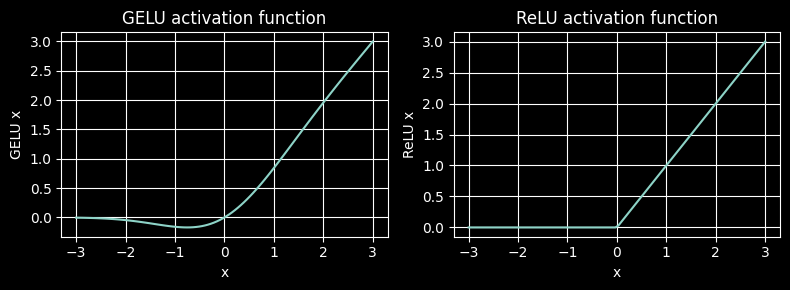

In [13]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), start=1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label} x")
    plt.grid(True)

plt.tight_layout()
plt.show()

#### A feed forward neural network module

In [14]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    def forward(self, x):
        return self.layers(x)

In [15]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
print(x)
out = ffn(x)
print(out.shape)

tensor([[[0.0351, 0.0028, 0.6470,  ..., 0.5897, 0.8112, 0.1335],
         [0.2758, 0.6665, 0.3312,  ..., 0.7204, 0.3365, 0.9016],
         [0.7622, 0.4008, 0.4706,  ..., 0.4857, 0.9844, 0.0499]],

        [[0.8761, 0.8123, 0.2511,  ..., 0.8113, 0.3147, 0.6469],
         [0.9920, 0.7436, 0.7393,  ..., 0.8690, 0.1667, 0.4374],
         [0.8999, 0.0747, 0.1878,  ..., 0.0586, 0.7915, 0.8741]]])
torch.Size([2, 3, 768])


####  A neural network to illustrate shortcut connections

In [16]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                          GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [17]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

In [18]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [19]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


In [20]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


#### The transformer block component of GPT

In [21]:
# 导入PyTorch的神经网络模块
import torch
import torch.nn as nn

# 从自定义模块导入多头注意力机制类
from MultiHeadAttention import MultiHeadAttention

class TransformerBlock(nn.Module):
    """
    Transformer的核心模块（编码器/解码器块）
    包含：多头自注意力层 + 前馈神经网络层 + 残差连接 + 层归一化
    采用Pre-LN结构（归一化在注意力/前馈层之前）
    """
    def __init__(self, cfg):
        super().__init__()  # 初始化父类nn.Module

        # 1. 初始化多头自注意力层
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],          # 输入特征维度（嵌入维度）
            d_out=cfg["emb_dim"],         # 输出特征维度（与输入一致）
            context_length=cfg["context_length"],  # 上下文长度（序列最大长度）
            num_heads=cfg["n_heads"],     # 注意力头数
            dropout=cfg["drop_rate"],     # Dropout概率
            qkv_bias=cfg["qkv_bias"]      # QKV线性层是否使用偏置
        )

        # 2. 初始化前馈神经网络层
        self.ff = FeedForward(cfg)

        # 3. 初始化两个层归一化层（分别用于注意力和前馈层）
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # 4. 初始化残差连接的Dropout层（防止过拟合）
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        """
        前向传播函数（Pre-LN结构）
        Args:
            x: 输入张量，形状为 [batch_size, seq_len, emb_dim]
        Returns:
            输出张量，形状与输入一致
        """
        # ========== 第一部分：多头自注意力层 + 残差连接 ==========
        shortcut = x  # 保存残差连接的原始输入
        x = self.norm1(x)  # 先做层归一化（Pre-LN结构核心）
        x = self.att(x)    # 多头自注意力计算
        x = self.drop_shortcut(x)  # 对注意力输出做Dropout
        x = x + shortcut   # 残差连接（将原始输入与注意力输出相加）

        # ========== 第二部分：前馈神经网络层 + 残差连接 ==========
        shortcut = x  # 保存注意力层输出作为残差连接的输入
        x = self.norm2(x)  # 再次做层归一化
        x = self.ff(x)     # 前馈神经网络计算
        x = self.drop_shortcut(x)  # 对前馈输出做Dropout
        x = x + shortcut   # 残差连接（将注意力输出与前馈输出相加）

        return x  # 返回Transformer块的最终输出

In [22]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


### Coding the GPT model

In [23]:
class GPTModel(nn.Module):
    """
    GPT（Generative Pre-trained Transformer）核心模型实现
    自回归语言模型的基础架构，包含：嵌入层 → 位置编码 → Transformer块堆叠 → 输出头
    核心特点：仅用Transformer解码器结构（自注意力），无编码器，纯自回归生成
    """
    def __init__(self, cfg):
        super().__init__()  # 初始化父类nn.Module

        # 1. 词嵌入层：将token索引映射为固定维度的向量
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        # 2. 位置嵌入层：将位置索引映射为固定维度的向量（GPT用绝对位置编码）
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        # 3. 嵌入层Dropout：防止嵌入层过拟合
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # 4. 堆叠多个TransformerBlock（核心编码层）
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # 5. 最终层归一化：稳定输出分布，提升训练效果
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # 6. 输出头：将嵌入维度映射回词汇表大小，生成每个token的预测概率
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        """
        GPT模型前向传播
        Args:
            in_idx: 输入token索引张量，形状 [batch_size, seq_len]
                    例如：[[12, 34, 56], [78, 90, 11]] （批次大小2，序列长度3）
        Returns:
            logits: 每个token的预测得分，形状 [batch_size, seq_len, vocab_size]
                    logits经过softmax后可得到每个位置的token概率分布
        """
        # 获取输入的批次大小和序列长度
        batch_size, seq_len = in_idx.shape

        # 步骤1：词嵌入 → [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)

        # 步骤2：位置嵌入
        # 生成0到seq_len-1的位置索引 → [seq_len]
        pos_idx = torch.arange(seq_len, device=tok_embeds.device)
        # 位置嵌入 → [seq_len, emb_dim]
        pos_embeds = self.pos_emb(pos_idx)
        # 词嵌入 + 位置嵌入（广播机制：pos_embeds自动扩展为[batch_size, seq_len, emb_dim]）
        x = tok_embeds + pos_embeds

        # 步骤3：嵌入层Dropout
        x = self.drop_emb(x)

        # 步骤4：通过堆叠的TransformerBlock进行特征编码
        x = self.trf_blocks(x)

        # 步骤5：最终层归一化
        x = self.final_norm(x)

        # 步骤6：输出头生成logits
        logits = self.out_head(x)

        return logits

In [24]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [25]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [26]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [27]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [28]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


### Generating text

#### A function for the GPT model to generate text

In [29]:
def generate_text_simple(model, idx,
                 max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probs, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [30]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [31]:
model = model.eval()
out = generate_text_simple(
    model,
    encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [32]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
